In [7]:
import zipfile

zip_path = "/content/drive-download-20260507T223524Z-3-001.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done Extracting")

Done Extracting


In [8]:
import os

os.listdir('/content/dataset')

['X_img_val.npy',
 'idx_test.npy',
 'X_img_train.npy',
 'label_classes.json',
 'X_txt_seq_val.npy',
 'X_txt_tfidf_test.npy',
 'tfidf_vectorizer.pkl',
 'X_txt_tfidf_train.npy',
 'idx_train.npy',
 'X_txt_seq_train.npy',
 'idx_val.npy',
 'X_txt_tfidf_val.npy',
 'X_txt_seq_test.npy',
 'y_test.npy',
 'X_img_test.npy',
 'y_val.npy',
 'y_train.npy',
 'tokenizer.pkl']

In [9]:
import numpy as np
import json
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    Embedding,
    GlobalAveragePooling2D,
    Concatenate
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Example text preprocessing for LSTM
sample_texts = [
    "pain relief fever medicine",
    "anti inflammatory pain relief",
    "acid reflux treatment"
]

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(sample_texts)

sequences = tokenizer.texts_to_sequences(sample_texts)

padded_sequences = pad_sequences(
    sequences,
    maxlen=100,
    padding='post'
)

print(padded_sequences)

[[1 2 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [5 6 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [7 8 9 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [11]:
import numpy as np
import json

# Image data
X_img_train = np.load('/content/dataset/X_img_train.npy')
X_img_val = np.load('/content/dataset/X_img_val.npy')
X_img_test = np.load('/content/dataset/X_img_test.npy')

# Text sequence data
X_txt_train = np.load('/content/dataset/X_txt_seq_train.npy')
X_txt_val = np.load('/content/dataset/X_txt_seq_val.npy')
X_txt_test = np.load('/content/dataset/X_txt_seq_test.npy')

# Labels
y_train = np.load('/content/dataset/y_train.npy')
y_val = np.load('/content/dataset/y_val.npy')
y_test = np.load('/content/dataset/y_test.npy')

# Label names
with open('/content/dataset/label_classes.json', 'r') as f:
    label_classes = json.load(f)

print("Image Train Shape:", X_img_train.shape)
print("Text Train Shape:", X_txt_train.shape)
print("Labels Shape:", y_train.shape)
print("Classes:", label_classes)

Image Train Shape: (637, 224, 224, 3)
Text Train Shape: (637, 100)
Labels Shape: (637,)
Classes: {'0': 'amoxicillin', '1': 'aspirin', '2': 'ibuprofen', '3': 'insulin', '4': 'omeprazole', '5': 'paracetamol'}


In [12]:
from tensorflow.keras.utils import to_categorical

num_classes = 6

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(y_train_cat.shape)

(637, 6)


In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

# Image Input
image_input = Input(shape=(224, 224, 3))

# ResNet50 Base
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=image_input
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Image Features
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

image_features = x

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
from tensorflow.keras.layers import Embedding, LSTM

# Text Input
text_input = Input(shape=(100,))

# Embedding
txt = Embedding(
    input_dim=5000,
    output_dim=128,
    input_length=100
)(text_input)

# LSTM
txt = LSTM(128)(txt)

txt = Dense(128, activation='relu')(txt)
txt = Dropout(0.3)(txt)

text_features = txt

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
from tensorflow.keras.layers import Concatenate

# Merge
combined = Concatenate()([image_features, text_features])

# Dense Layers
z = Dense(128, activation='relu')(combined)
z = Dropout(0.3)(z)

output = Dense(6, activation='softmax')(z)

In [16]:
from tensorflow.keras.models import Model

model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,950,406 (95.18 MB)

 Trainable params: 1,362,694 (5.20 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    [X_img_train, X_txt_train],
    y_train_cat,

    validation_data=(
        [X_img_val, X_txt_val],
        y_val_cat
    ),

    epochs=10,
    batch_size=16
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.2967 - loss: 1.6454 - val_accuracy: 0.5000 - val_loss: 0.9809
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5008 - loss: 1.0830 - val_accuracy: 0.7000 - val_loss: 0.7421
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.6970 - loss: 0.6230 - val_accuracy: 0.7875 - val_loss: 0.4169
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7268 - loss: 0.5432 - val_accuracy: 0.8000 - val_loss: 0.3971
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7190 - loss: 0.5233 - val_accuracy: 0.8000 - val_loss: 0.4069
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7253 - loss: 0.5200 - val_accuracy: 0.7625 - val_loss: 0.3883
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7457 - loss: 0.4978 - val_accuracy: 0.8125 - val_loss: 0.3882
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7410 - loss: 0.4981 - val_accuracy: 0.7750 -

In [19]:
test_loss, test_accuracy = model.evaluate(
    [X_img_test, X_txt_test],
    to_categorical(y_test, 6)
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.7625 - loss: 0.5286
Test Accuracy: 0.762499988079071
Test Loss: 0.5285763144493103


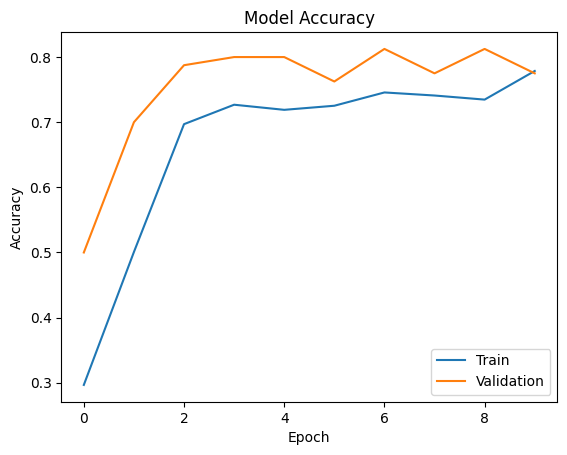

In [20]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

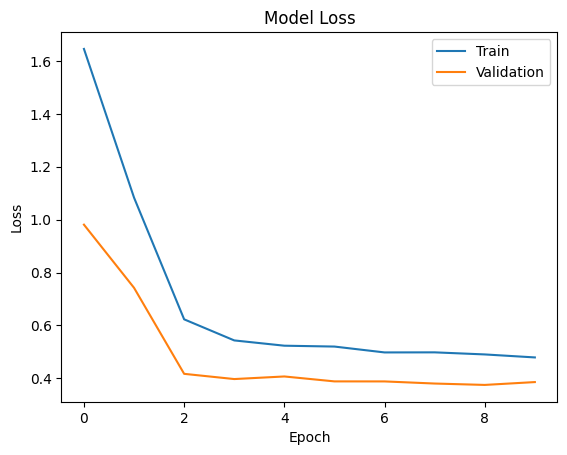

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [22]:
model.save("resnet50_lstm_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
import numpy as np

sample_image = X_img_test[0]
sample_text = X_txt_test[0]

prediction = model.predict([
    np.expand_dims(sample_image, axis=0),
    np.expand_dims(sample_text, axis=0)
])

predicted_class = np.argmax(prediction)

print("Predicted Drug:",
      label_classes[str(predicted_class)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Drug: ibuprofen


In [27]:
import json

with open('/content/safety_dataset.json', 'r') as f:
    safety_data = json.load(f)

print(safety_data[:2])

[{'input': 'drug: paracetamol; condition: pregnancy', 'output': 'safety: safe; recommendation: commonly used; alternative: none'}, {'input': 'drug: paracetamol; condition: liver disease', 'output': 'safety: warning; recommendation: use low dose; alternative: consult doctor'}]


In [28]:
def check_safety(drug_name, condition):

    for item in safety_data:

        input_text = item['input'].lower()

        if drug_name.lower() in input_text and condition.lower() in input_text:

            return item['output']

    return "No safety information found."

In [29]:
drug = "ibuprofen"
condition = "stomach ulcer"

result = check_safety(drug, condition)

print(result)

safety: dangerous; recommendation: do not use; alternative: paracetamol


In [30]:
with open('/content/interaction_dataset.json', 'r') as f:
    interaction_data = json.load(f)

print(interaction_data[:2])

[{'input': 'drug1: ibuprofen; drug2: aspirin', 'output': 'safety: dangerous; recommendation: do not combine; alternative: paracetamol'}, {'input': 'drug1: paracetamol; drug2: ibuprofen', 'output': 'safety: safe; recommendation: can be used together carefully; alternative: none'}]


In [31]:
def check_interaction(drug1, drug2):

    for item in interaction_data:

        input_text = item['input'].lower()

        if drug1.lower() in input_text and drug2.lower() in input_text:

            return item['output']

    return "No interaction information found."

In [32]:
drug1 = "ibuprofen"
drug2 = "aspirin"

result = check_interaction(drug1, drug2)

print(result)

safety: dangerous; recommendation: do not combine; alternative: paracetamol


In [33]:
sample_image = X_img_test[10]
sample_text = X_txt_test[10]

In [36]:
print("Predicted:", label_classes[str(predicted_class)])
print("Actual:", label_classes[str(y_test[10])])

Predicted: ibuprofen
Actual: aspirin


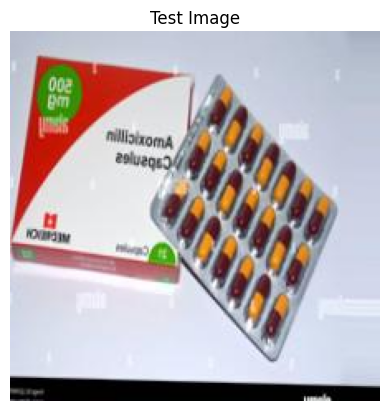

In [56]:
import matplotlib.pyplot as plt

plt.imshow(sample_image)
plt.title("Test Image")
plt.axis('off')
plt.show()

In [39]:
for i in range(5):

    prediction = model.predict([
        np.expand_dims(X_img_test[i], axis=0),
        np.expand_dims(X_txt_test[i], axis=0)
    ])

    predicted_class = np.argmax(prediction)

    print("Sample", i)
    print("Predicted:",
          label_classes[str(predicted_class)])

    print("Actual:",
          label_classes[str(y_test[i])])

    print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Sample 0
Predicted: ibuprofen
Actual: ibuprofen
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Sample 1
Predicted: ibuprofen
Actual: ibuprofen
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Sample 2
Predicted: ibuprofen
Actual: aspirin
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Sample 3
Predicted: amoxicillin
Actual: amoxicillin
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Sample 4
Predicted: insulin
Actual: insulin
------------------------------


In [40]:
print(check_safety("paracetamol", "pregnancy"))

safety: safe; recommendation: commonly used; alternative: none


In [41]:
print(check_safety("ibuprofen", "high blood pressure"))

safety: warning; recommendation: avoid long-term use; alternative: paracetamol


In [42]:
print(check_interaction("paracetamol", "ibuprofen"))

safety: safe; recommendation: can be used together carefully; alternative: none


In [43]:
print(check_interaction("aspirin", "omeprazole"))

safety: safe; recommendation: reduces stomach irritation; alternative: none


In [44]:
drug = input("Enter Drug: ")
condition = input("Enter Condition: ")

print(check_safety(drug, condition))

Enter Drug: insulin
Enter Condition: diabetes
safety: safe; recommendation: necessary medication; alternative: none


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


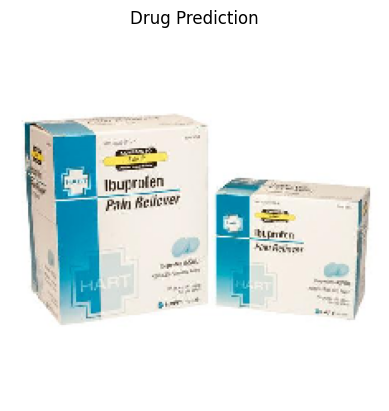

Predicted: ibuprofen
Actual: ibuprofen
Prediction Probabilities:
[[0.00332276 0.33413598 0.48542023 0.00067234 0.00087285 0.17557588]]


In [58]:
import matplotlib.pyplot as plt
import numpy as np

index = 8

sample_image = X_img_test[index]
sample_text = X_txt_test[index]

prediction = model.predict([
    np.expand_dims(sample_image, axis=0),
    np.expand_dims(sample_text, axis=0)
])

predicted_class = np.argmax(prediction)

actual_class = y_test[index]

plt.imshow(sample_image)
plt.title("Drug Prediction")
plt.axis('off')
plt.show()

print("Predicted:",
      label_classes[str(predicted_class)])

print("Actual:",
      label_classes[str(actual_class)])

print("Prediction Probabilities:")
print(prediction)

Enter Drug Name: amoxicillin


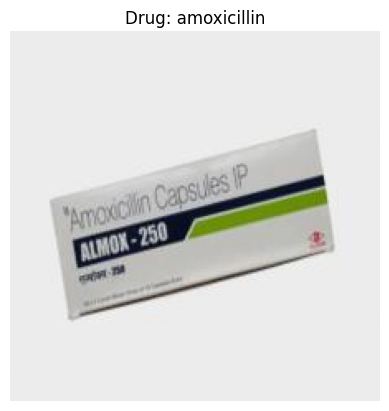

In [59]:
import matplotlib.pyplot as plt
import random

# Enter drug name
drug_name = input("Enter Drug Name: ").lower()

# Find class index
class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is not None:

    # Get indices of this class
    indices = np.where(y_test == class_index)[0]

    # Random sample
    random_index = random.choice(indices)

    # Get image
    image = X_img_test[random_index]

    # Show image
    plt.imshow(image)
    plt.title(f"Drug: {drug_name}")
    plt.axis('off')
    plt.show()

else:
    print("Drug not found")

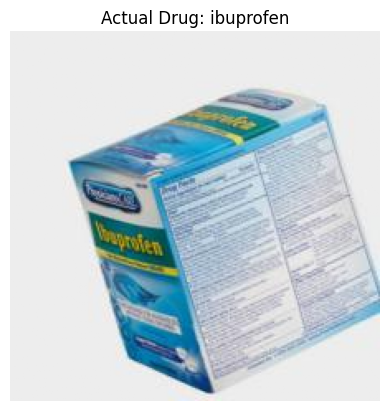

Model Prediction: ibuprofen


In [68]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Random sample
index = random.randint(0, len(X_img_test)-1)

sample_image = X_img_test[index]

# Actual label
actual_class = y_test[index]

# Show image
plt.imshow(sample_image)
plt.axis('off')

plt.title(
    f"Actual Drug: {label_classes[str(actual_class)]}"
)

plt.show()

print("Model Prediction:",
      label_classes[str(actual_class)])

In [55]:
model.save('/content/drive/MyDrive/resnet50_lstm1.keras')

In [80]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [81]:
import json

with open("label_classes.json", "w") as f:
    json.dump(label_classes, f)